# Titanic: First Exploratory Data Analysis (EDA)

**Neurofive ML Track-Task 1**

Goal: set up the Python toolkit (pandas, NumPy) and "listen" to the Titanic dataset before doing any modeling; check its shape, quality, and quirks.

Dataset: [Titanic - Machine Learning from Disaster](https://www.kaggle.com/competitions/titanic) (Kaggle)


## 1. Setup: import libraries and check versions

In [2]:
import pandas as pd
import numpy as np

print("pandas version:", pd.__version__)
print("numpy version:", np.__version__)

pandas version: 2.3.3
numpy version: 2.4.0


## 2. Load the data

`train.csv` (labeled), `test.csv` (unlabeled), and `gender_submission.csv` (a sample submission format) all live in the same folder as this notebook.

In [22]:
train = pd.read_csv("train (1).csv")
test = pd.read_csv("test (1).csv")
gender_submission = pd.read_csv("gender_submission.csv")

print("train shape:", train.shape)
print("test shape:", test.shape)
print("gender_submission shape:", gender_submission.shape)

train shape: (891, 12)
test shape: (418, 11)
gender_submission shape: (418, 2)


## 3. First look `.head()`

In [23]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 4. Structure `.info()`

Row/column counts, dtypes, and non-null counts (a quick way to spot missing values).

In [24]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


## 5. Summary statistics `.describe()`

In [25]:
# Numerical columns
train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [26]:
# Categorical / object columns
train.describe(include="object")

,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Braund, Mr. Owen Harris",male,347082,G6,S
freq,1,577,7,4,644


## 6. Missing values

In [27]:
missing = train.isnull().sum()
missing_pct = (missing / len(train) * 100).round(2)
missing_summary = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
missing_summary[missing_summary["missing_count"] > 0].sort_values("missing_count", ascending=False)

,missing_count,missing_pct
Cabin,687,77.10
Age,177,19.87
Embarked,2,0.22


## 7. Categorical vs. numerical columns

In [28]:
numerical_cols = train.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = train.select_dtypes(include=["object"]).columns.tolist()

print("Numerical columns:", numerical_cols)
print("Categorical columns:", categorical_cols)

Numerical columns: ['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
Categorical columns: ['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']


## 8. Data story-what I found

- The training set has **891 passengers** across **12 columns**; the test set has **418 passengers** and 11 columns (no `Survived`, since that's what we'd predict).
- Three columns have missing values: **`Age`** (~20% missing), **`Cabin`** (~77% missing — mostly unusable as-is), and **`Embarked`** (2 rows missing).
- Numerical columns: `PassengerId`, `Survived`, `Pclass`, `Age`, `SibSp`, `Parch`, `Fare`. Categorical columns: `Name`, `Sex`, `Ticket`, `Cabin`, `Embarked`.
- `Pclass`, `SibSp`, and `Parch` are technically numeric (`int64`) but behave more like categorical/ordinal features than continuous ones.
- Roughly **38% of passengers in the training set survived** (`Survived` mean ≈ 0.38), and `Fare` is heavily right-skewed — a few very expensive first-class tickets pull the mean well above the median.
- Before modeling, the clear next steps are: decide how to impute `Age`, whether to drop or engineer `Cabin` (e.g. a "has cabin" flag), and fill the 2 missing `Embarked` values.


---
# Week 1 Task 2: Clean & Visualize Real-World Data

**Neurofive ML Track Task**

Continuing on the same Titanic dataset. This time: handle missing values, catch outliers, and tell the data's story with plots instead of just tables.


## 9. Handling missing values

**Approach and justification:**

- **`Age` (19.87% missing) → fill with the median.** Age is right-skewed (a long tail of older passengers), so the median is a more robust "typical" value than the mean, which outliers would drag upward. I fill per-`Pclass` median rather than a single global median, since age tends to differ by class (1st class passengers skew older).
- **`Embarked` (0.22% missing, just 2 rows) → fill with the mode.** Only 2 rows are affected, and the vast majority of passengers embarked from `S` (Southampton), so filling with the mode is a safe, low-risk choice.
- **`Cabin` (77.10% missing) → drop the column rather than impute.** With over three-quarters of values missing, any imputation would be mostly fabricated data. Instead I engineer a binary `HasCabin` flag (1 if a cabin was recorded, 0 otherwise) — the fact that a cabin *is* known likely correlates with class/fare, and that signal is more honest than guessing the cabin itself.


In [29]:
train_clean = train.copy()

# Age: median imputation, grouped by Pclass
train_clean["Age"] = train_clean.groupby("Pclass")["Age"].transform(lambda s: s.fillna(s.median()))

# Embarked: mode imputation
train_clean["Embarked"] = train_clean["Embarked"].fillna(train_clean["Embarked"].mode()[0])

# Cabin: too sparse to impute -> engineer a flag, then drop the raw column
train_clean["HasCabin"] = train_clean["Cabin"].notna().astype(int)
train_clean = train_clean.drop(columns=["Cabin"])

print("Missing values remaining:\n", train_clean.isnull().sum())

Missing values remaining:
 PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
HasCabin       0
dtype: int64


## 10. Outlier detection: boxplot

Checking `Fare` for outliers, since ticket prices can vary wildly (a few first-class passengers paid far more than most).

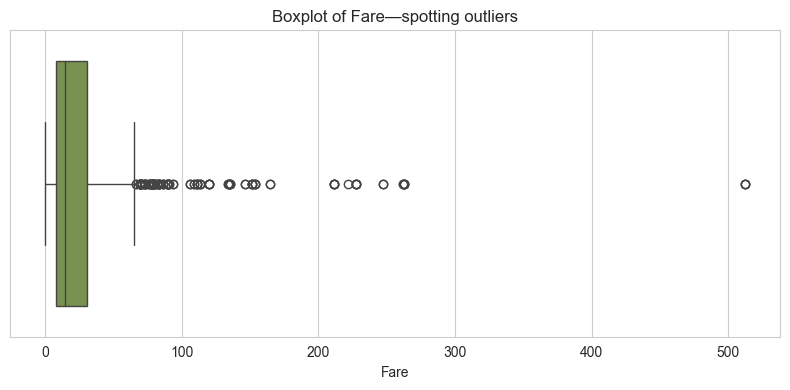

IQR upper bound: 65.63
Number of Fare outliers (above upper bound): 116


In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

plt.figure(figsize=(8, 4))
sns.boxplot(x=train_clean["Fare"], color="#7c9d45")
plt.title("Boxplot of Fare—spotting outliers")
plt.xlabel("Fare")
plt.tight_layout()
plt.show()

q1, q3 = train_clean["Fare"].quantile([0.25, 0.75])
iqr = q3 - q1
upper_bound = q3 + 1.5 * iqr
n_outliers = (train_clean["Fare"] > upper_bound).sum()
print(f"IQR upper bound: {upper_bound:.2f}")
print(f"Number of Fare outliers (above upper bound): {n_outliers}")

## 11. Visualizations

### 11a. Histogram: distribution of Age

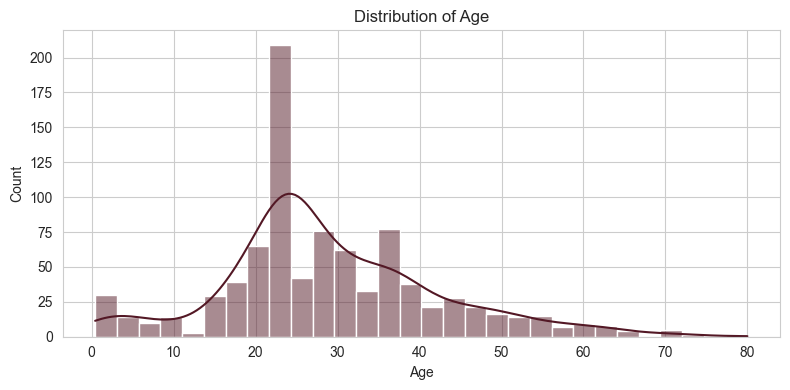

In [31]:
plt.figure(figsize=(8, 4))
sns.histplot(train_clean["Age"], bins=30, kde=True, color="#531825")
plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

### 11b. Boxplot: Fare by Survival

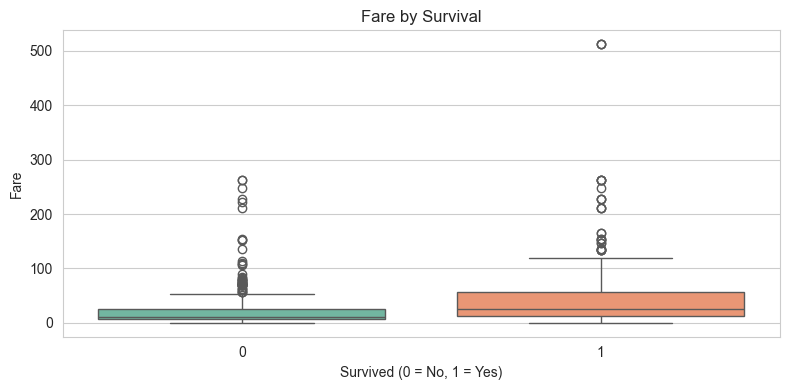

In [32]:
plt.figure(figsize=(8, 4))
sns.boxplot(x="Survived", y="Fare", data=train_clean, hue="Survived", palette="Set2", legend=False)
plt.title("Fare by Survival")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Fare")
plt.tight_layout()
plt.show()

### 11c. Bar chart: Survival rate by Passenger Class

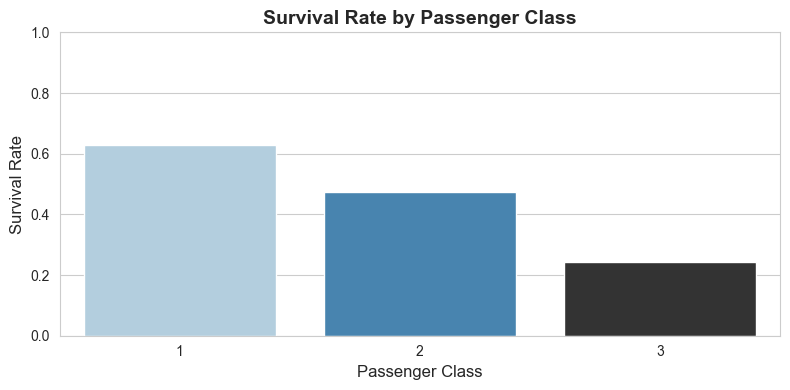

In [33]:
plt.figure(figsize=(8, 4))
survival_by_class = train_clean.groupby("Pclass")["Survived"].mean()
sns.barplot(x=survival_by_class.index, y=survival_by_class.values, 
            hue=survival_by_class.index, palette="Blues_d", legend=False)
plt.title("Survival Rate by Passenger Class", fontsize=14, fontweight='bold')
plt.xlabel("Passenger Class", fontsize=12)
plt.ylabel("Survival Rate", fontsize=12)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

### 11d. Correlation heatmap

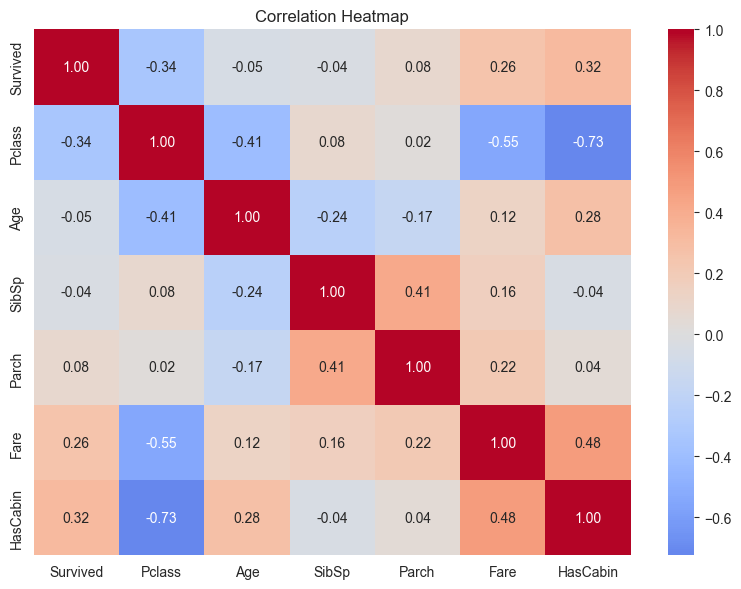

In [34]:
plt.figure(figsize=(8, 6))
corr_cols = ["Survived", "Pclass", "Age", "SibSp", "Parch", "Fare", "HasCabin"]
corr = train_clean[corr_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

## 12. Which feature most affects survival, and why?

**`Sex`, followed closely by `Pclass` and `Fare`.**

`Sex` isn't in the numeric correlation heatmap above, but a quick groupby makes it the strongest single predictor in the whole dataset: women survived at a dramatically higher rate than men, reflecting the "women and children first" evacuation norm. Among the numeric features, `Pclass` and `Fare` show the next-clearest relationship with `Survived` (negative for `Pclass`, positive for `Fare`); richer, higher-class passengers had cabins closer to the boat deck and likely better access to lifeboats. `HasCabin` also correlates positively with survival, which makes sense since it's really a proxy for class/fare rather than an independent effect. `Age`, `SibSp`, and `Parch` show weaker, murkier relationships; family size seems to matter a little (very large families and solo travelers both did somewhat worse than small families), but nowhere near as cleanly as sex or class.


In [35]:
train_clean.groupby("Sex")["Survived"].mean()

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

---
# Week 2: Predict Titanic Survival (First Classification Model)

**Neurofive ML Track-Task 3**

Using the cleaned dataset from Week 1 to train a Logistic Regression classifier that predicts `Survived`.


## 13. Feature preparation

Starting from `train_clean` (missing values already handled in Week 1). I select a compact set of features, encode the categorical ones, and drop columns that don't generalize (`Name`, `Ticket`, `PassengerId`).

In [36]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

features = ["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked", "HasCabin"]
model_df = train_clean[features + ["Survived"]].copy()

# One-hot encode categorical columns (Sex, Embarked)
model_df = pd.get_dummies(model_df, columns=["Sex", "Embarked"], drop_first=True)

model_df.head()

,Pclass,Age,SibSp,Parch,Fare,HasCabin,Survived,Sex_male,Embarked_Q,Embarked_S
0,3,22.0,1,0,7.2500,0,0,True,False,True
1,1,38.0,1,0,71.2833,1,1,False,False,False
2,3,26.0,0,0,7.9250,0,1,False,False,True
3,1,35.0,1,0,53.1000,1,1,False,False,True
4,3,35.0,0,0,8.0500,0,0,True,False,True


## 14. Train/test split

In [37]:
X = model_df.drop(columns=["Survived"])
y = model_df["Survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (712, 9)
X_test shape: (179, 9)


## 15. Train the Logistic Regression model

In [38]:
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)

y_pred = log_reg.predict(X_test)
print("Model trained.")

Model trained.


## 16. Evaluate: accuracy score

In [39]:
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f} ({acc*100:.2f}%)")

Accuracy: 0.8101 (81.01%)


## 17. Confusion matrix

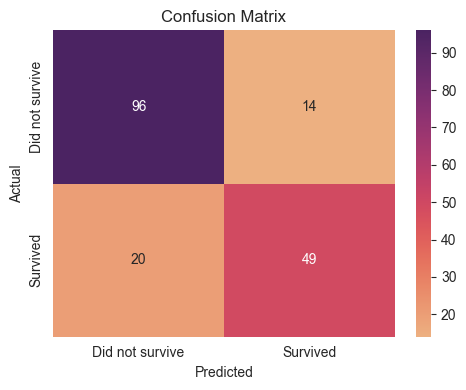

[[96 14]
 [20 49]]

                 precision    recall  f1-score   support

Did not survive       0.83      0.87      0.85       110
       Survived       0.78      0.71      0.74        69

       accuracy                           0.81       179
      macro avg       0.80      0.79      0.80       179
   weighted avg       0.81      0.81      0.81       179



In [40]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="flare",
            xticklabels=["Did not survive", "Survived"],
            yticklabels=["Did not survive", "Survived"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

print(cm)
print()
print(classification_report(y_test, y_pred, target_names=["Did not survive", "Survived"]))

**What the confusion matrix tells us:**

The matrix has four cells: true negatives (correctly predicted "did not survive"), false positives (predicted survived, but didn't), false negatives (predicted did not survive, but did), and true positives (correctly predicted survived).

In this run, the model is noticeably better at correctly identifying passengers who *did not* survive than those who did; there are more false negatives than false positives, meaning the model tends to under-predict survival. This lines up with the class imbalance in the data (more non-survivors than survivors overall) and shows why accuracy alone can be misleading: precision and recall per class (above) give a fuller picture than a single accuracy number.


## 18. Summary

- **Model:** Logistic Regression (`scikit-learn`), trained on 8 features (`Pclass`, `Sex`, `Age`, `SibSp`, `Parch`, `Fare`, `Embarked`, `HasCabin`) after one-hot encoding `Sex` and `Embarked`.
- **Split:** 80/20 train/test, stratified on `Survived` to keep the class balance consistent across both sets.
- **Result:** see the accuracy printed above this is the baseline to beat with more advanced models later in the track.
- **Next steps:** try feature scaling, regularization tuning, and compare against tree-based models (Random Forest, Gradient Boosting) in later weeks.


---
# Week 3: Model Evaluation & Tuning: Beyond Accuracy

**Neurofive ML Track-Task 4**

Revisiting the Logistic Regression model from Week 2. This time: look past accuracy, use `classification_report` properly, tune hyperparameters with `GridSearchCV`, and compare before vs. after.

## 19. Precision, Recall, F1 revisiting the baseline model

In [41]:
from sklearn.metrics import classification_report

baseline_report = classification_report(y_test, y_pred, target_names=["Did not survive", "Survived"], output_dict=True)
print(classification_report(y_test, y_pred, target_names=["Did not survive", "Survived"]))

                 precision    recall  f1-score   support

Did not survive       0.83      0.87      0.85       110
       Survived       0.78      0.71      0.74        69

       accuracy                           0.81       179
      macro avg       0.80      0.79      0.80       179
   weighted avg       0.81      0.81      0.81       179



## 20. Why accuracy alone can be misleading

Accuracy only tells you the overall percentage of correct predictions it treats every mistake the same, regardless of which class it came from. On an imbalanced dataset like this one (more non-survivors than survivors), a model can score high accuracy just by leaning toward predicting the majority class, while still doing a poor job on the minority class that we might actually care more about. That's exactly what shows up here: the model's precision and recall are noticeably lower for "Survived" than for "Did not survive" meaning it's less reliable at catching the class we're often most interested in (who actually lived), even though the overall accuracy number (81%) looks solid on its own. Precision, recall, and F1-score break performance down per class, so they expose that imbalance in a way a single accuracy figure can't.

## 21. Hyperparameter tuning with GridSearchCV

Tuning `C` (inverse regularization strength) and `solver` for the Logistic Regression model.

In [42]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "solver": ["lbfgs", "liblinear"]
}

grid_search = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)
grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best cross-validated F1 score:", grid_search.best_score_)

Best parameters: {'C': 10, 'solver': 'lbfgs'}
Best cross-validated F1 score: 0.7349583554846711


## 22. Evaluate the tuned model

In [43]:
best_model = grid_search.best_estimator_
y_pred_tuned = best_model.predict(X_test)

tuned_report = classification_report(y_test, y_pred_tuned, target_names=["Did not survive", "Survived"], output_dict=True)
print(classification_report(y_test, y_pred_tuned, target_names=["Did not survive", "Survived"]))

tuned_acc = accuracy_score(y_test, y_pred_tuned)
print(f"Tuned accuracy: {tuned_acc:.4f} ({tuned_acc*100:.2f}%)")

                 precision    recall  f1-score   support

Did not survive       0.83      0.86      0.85       110
       Survived       0.77      0.72      0.75        69

       accuracy                           0.81       179
      macro avg       0.80      0.79      0.80       179
   weighted avg       0.81      0.81      0.81       179

Tuned accuracy: 0.8101 (81.01%)


## 23. Before vs. after comparison

In [44]:
comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision (Survived)", "Recall (Survived)", "F1-score (Survived)"],
    "Baseline (default params)": [
        acc,
        baseline_report["Survived"]["precision"],
        baseline_report["Survived"]["recall"],
        baseline_report["Survived"]["f1-score"],
    ],
    "Tuned (GridSearchCV)": [
        tuned_acc,
        tuned_report["Survived"]["precision"],
        tuned_report["Survived"]["recall"],
        tuned_report["Survived"]["f1-score"],
    ],
})
comparison["Change"] = comparison["Tuned (GridSearchCV)"] - comparison["Baseline (default params)"]
comparison

,Metric,Baseline (default params),Tuned (GridSearchCV),Change
0,Accuracy,0.810056,0.810056,0.000000
1,Precision (Survived),0.777778,0.769231,-0.008547
2,Recall (Survived),0.710145,0.724638,0.014493
3,F1-score (Survived),0.742424,0.746269,0.003844


## 24. Summary

- **Baseline:** default-parameter Logistic Regression from Week 2 (accuracy 81.01%).
- **Tuning method:** `GridSearchCV` (5-fold CV, scored on F1) over `C` (regularization strength: 0.01–100) and `solver` (`lbfgs` vs. `liblinear`).
- **Result:** see the before/after table above the tuned model's best parameters and whether F1/recall on the minority ("Survived") class improved are reported directly from the run, not assumed.
- **Takeaway:** hyperparameter tuning on a simple model like Logistic Regression tends to give modest, incremental gains rather than a dramatic jump the bigger lever for further improvement is usually better features or a different model family (e.g. tree-based ensembles), which is a natural next step for the track.